In [16]:
cd("/home/ritaferi/Phd/SSDdev/")
using Pkg
Pkg.activate(".")
Pkg.instantiate()

using SolidStateDetectors
using Unitful
using Plots
using LegendHDF5IO
using HDF5



  Activating project at `~/Phd/SSDdev`


In [17]:
using Random

In [18]:
voxel = 20.0              # micron. distanza lungo 2 punti consecutivi della griglia
size_mm = 2.0             # dimensione del volume (mm) Lx = Ly = Lz = 2 mm

# conversione mm → micron
size = size_mm * 1000.0

# numero di voxel per asse
nx = Int(size / voxel)
ny = Int(size / voxel)
nz = Int(size / voxel)

# profondità massima del layer Li
li_depth = 1000.0   # micron (1 mm)

# concentrazione massima alla superficie
max_concentration = 0.005   # 0.5 %



0.005

In [19]:
# -----------------------------
# Matrice dei precipitati
# -----------------------------

Li = falses(nx, ny, nz)

# -----------------------------
# Generazione distribuzione Li
# -----------------------------

for x in 1:nx   # x = depth

    depth = (x-1) * voxel

    if depth < li_depth
        conc = max_concentration * (1 - depth/li_depth)
    else
        conc = 0.0
    end

    for y in 1:ny, z in 1:nz
        if rand() < conc
            Li[x,y,z] = true
        end
    end
end


In [20]:
xs = Float64[]
ys = Float64[]
zs = Float64[]

for x in 1:nx, y in 1:ny, z in 1:nz
    if Li[x,y,z]
        push!(xs,(x-1)*voxel)
        push!(ys,(y-1)*voxel)
        push!(zs,(z-1)*voxel)
    end
end

In [24]:
Lx = 2000
Ly=2000
Lz=2000

2000

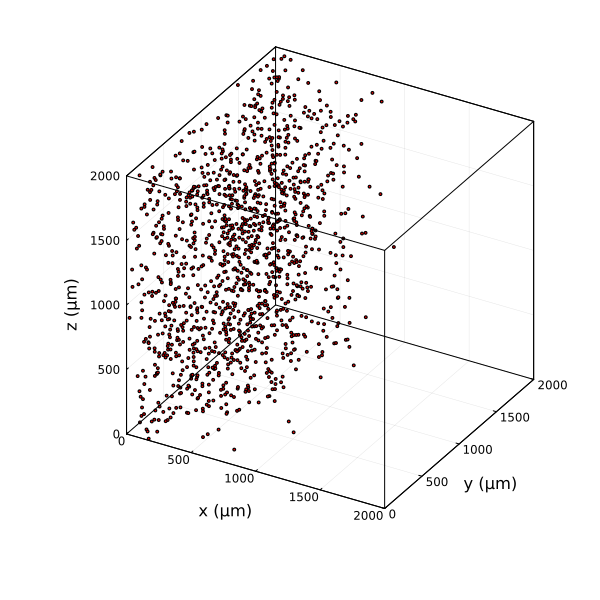

In [30]:
p = scatter(xs, ys, zs,
    markersize=1.5,
    color = :red,
    xlabel="x (μm)", ylabel="y (μm)", zlabel="z (μm)",
    xlim=(0,2000), ylim=(0,2000), zlim=(0,2000),
    legend=false, frame=:box, size=(600,600)
)

Lx_um, Ly_um, Lz_um = 2000, 2000, 2000
xv = [0, Lx_um]; yv = [0, Ly_um]; zv = [0, Lz_um]

for x in xv, y in yv
    plot!(p, [x, x], [y, y], [0, Lz_um], lc=:black)
end
for x in xv, z in zv
    plot!(p, [x, x], [0, Ly_um], [z, z], lc=:black)
end
for y in yv, z in zv
    plot!(p, [0, Lx_um], [y, y], [z, z], lc=:black)
end

display(p)